In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler


**Dataset:**

Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Infromation and Computer Science.


Donates by: P Savicky Institute of Computer Science, AS of CR Czech Republic savicky '@'cs.cas.cz


In [ ]:

cols=["fLength", "fWidth", "fSize", "fCone", "fCone1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df=pd.read_csv("magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fCone,fCone1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [ ]:
df["class"]= (df["class"]== "g").astype(int)

In [ ]:
df.head()

,fLength,fWidth,fSize,fCone,fCone1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


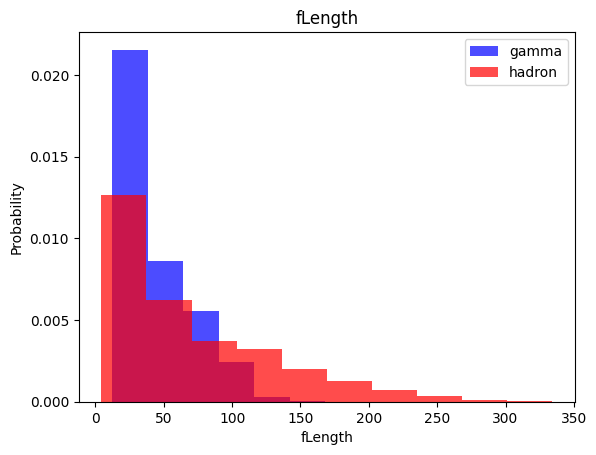

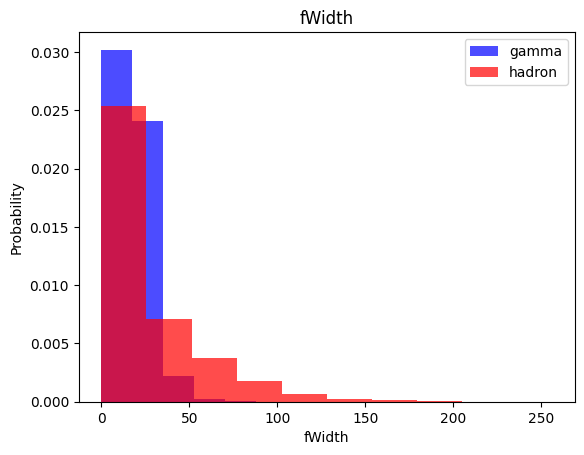

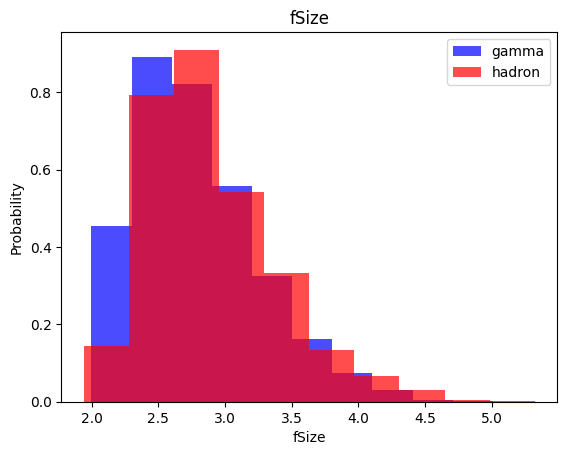

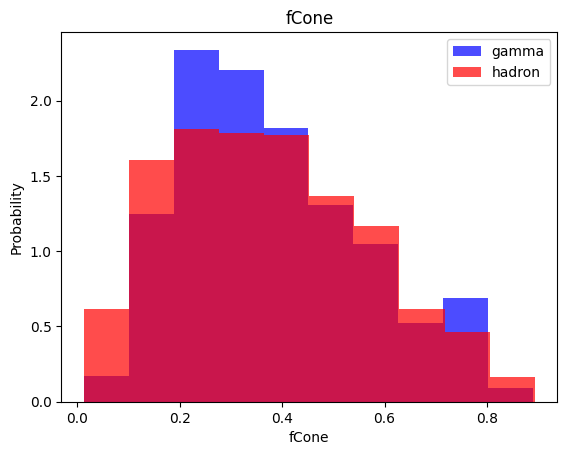

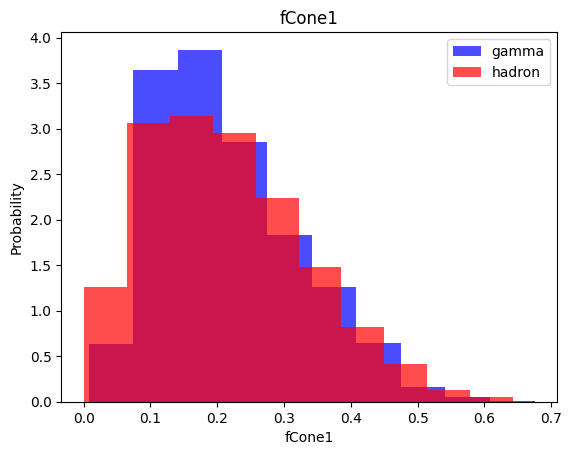

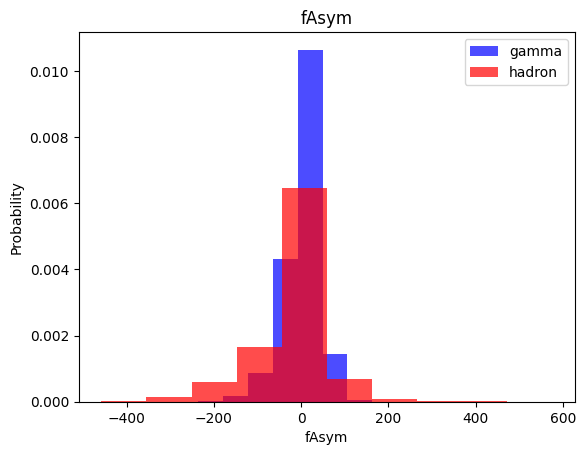

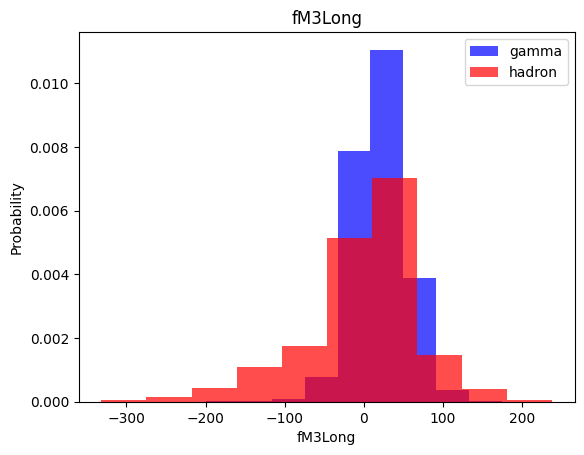

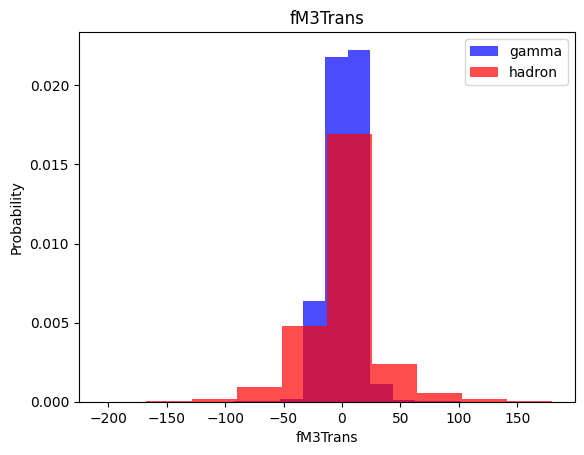

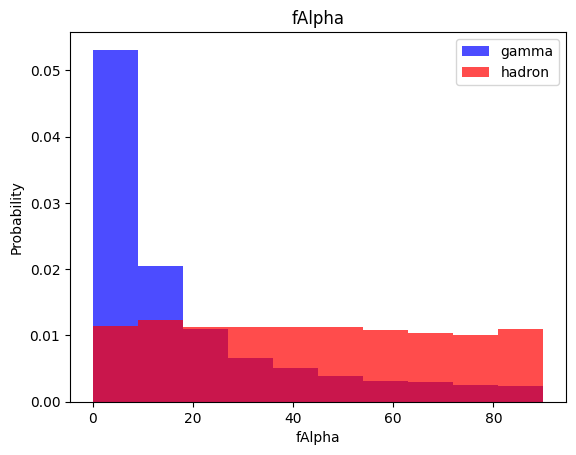

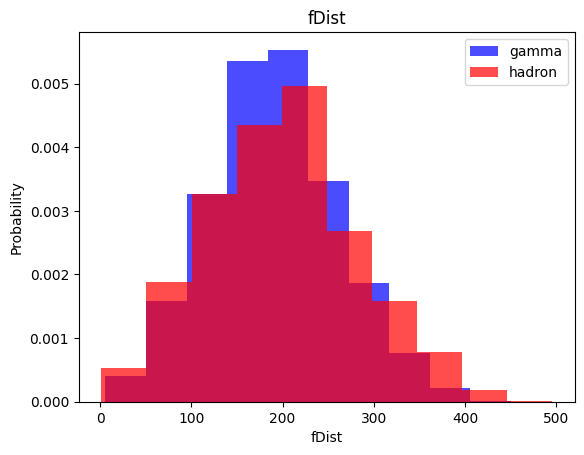

In [ ]:
for label in cols[:-1]:
  plt.hist(df[df["class"]==1][label], color='blue', label='gamma', alpha=0.7, density=True)
  plt.hist(df[df["class"]==0][label], color='red', label='hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

#Train, validation, test datasets

In [ ]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
def scale_dataset(dataframe, oversample=False):
  X= dataframe[dataframe.columns[:-1]].values
  Y= dataframe[dataframe.columns[-1]].values # Corrected this line

  scaler= StandardScaler()
  X= scaler.fit_transform(X)

  if oversample:
    ros= RandomOverSampler()
    X,Y= ros.fit_resample(X, Y)

  data= np.hstack((X, np.reshape(Y, (-1,1))))

  return data, X, Y

In [ ]:
train, X_train, Y_train= scale_dataset(train, oversample=True)
valid, X_valid, Y_valid= scale_dataset(valid, oversample=False)
test, X_test, Y_test= scale_dataset(test, oversample=False)

# kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [ ]:
knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)

KNeighborsClassifier()

In [ ]:
y_pred= knn_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.75      0.74      1303
           1       0.87      0.87      0.87      2501

    accuracy                           0.82      3804
   macro avg       0.81      0.81      0.81      3804
weighted avg       0.82      0.82      0.82      3804



# Naive Bayes


In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model= GaussianNB()
nb_model= nb_model.fit(X_train, Y_train)

In [ ]:
y_pred= nb_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.40      0.49      1303
           1       0.74      0.89      0.81      2501

    accuracy                           0.72      3804
   macro avg       0.69      0.64      0.65      3804
weighted avg       0.71      0.72      0.70      3804



# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model= LogisticRegression()
lg_model= lg_model.fit(X_train, Y_train)

In [ ]:
y_pred= lg_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.72      0.69      1303
           1       0.85      0.81      0.83      2501

    accuracy                           0.78      3804
   macro avg       0.76      0.77      0.76      3804
weighted avg       0.79      0.78      0.78      3804



# SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model= SVC()
svm_model= svm_model.fit(X_train, Y_train)

In [ ]:
y_pred= svm_model.predict(X_test)

In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1303
           1       0.90      0.89      0.90      2501

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.87      0.86      0.86      3804



# Neural Network

In [ ]:
import tensorflow as tf

In [ ]:
def train_model(X_train, Y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    nn_model= tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

    nn_model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy'])

    history= nn_model.fit(X_train, Y_train, validation_split=0.2, batch_size=batch_size, epochs=epochs)

    return nn_model, history

In [ ]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  plt.show()


In [ ]:
plot_history(history)

NameError: name 'history' is not defined

num_nodes: 16, dropout_prob: 0, lr: 0.01, batch_size: 32
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


369/369 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8215 - loss: 0.3987 - val_accuracy: 0.7322 - val_loss: 0.5078
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8545 - loss: 0.3492 - val_accuracy: 0.7227 - val_loss: 0.5225
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8607 - loss: 0.3318 - val_accuracy: 0.7597 - val_loss: 0.4816
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8635 - loss: 0.3260 - val_accuracy: 0.7963 - val_loss: 0.4296
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8672 - loss: 0.3224 - val_accuracy: 0.7702 - val_loss: 0.4439
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8646 - loss: 0.3204 - val_accuracy: 0.7505 - val_loss: 0.5168
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8679 - loss: 0.3179 - val_accuracy: 0.7197 - val_loss: 0.5260
Epoch 8/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8716 - loss: 0.3124 - val_accuracy: 0.7363

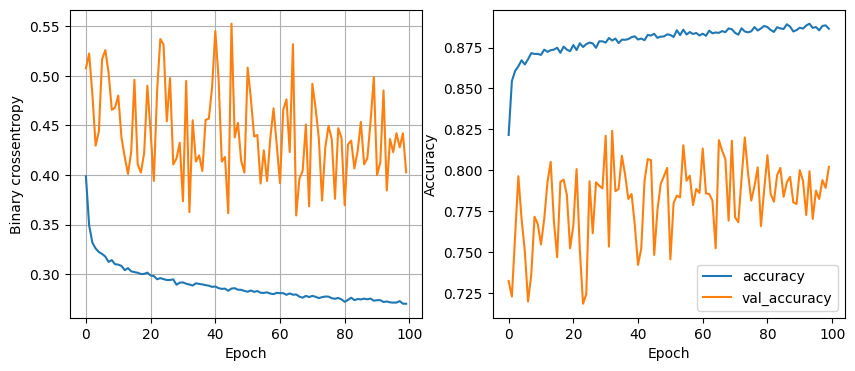

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8667 - loss: 0.3337
num_nodes: 16, dropout_prob: 0, lr: 0.01, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8225 - loss: 0.4004 - val_accuracy: 0.7353 - val_loss: 0.5121
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8501 - loss: 0.3483 - val_accuracy: 0.6844 - val_loss: 0.6196
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8551 - loss: 0.3377 - val_accuracy: 0.7627 - val_loss: 0.4565
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8611 - loss: 0.3283 - val_accuracy: 0.7108 - val_loss: 0.5567
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8596 - loss: 0.3266 - val_accuracy: 0.7644 - val_loss: 0.4506
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8658 - loss: 0.3198 - val_accuracy: 0.7505 - val_loss: 0.5004
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8677 - loss: 0.3159 - val_a

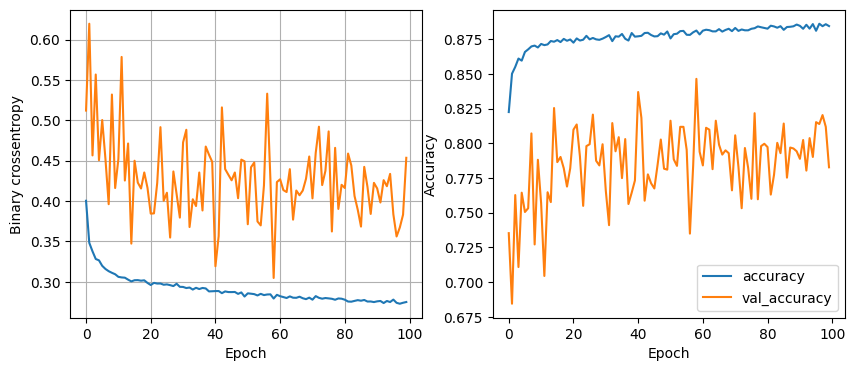

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8728 - loss: 0.3165
num_nodes: 16, dropout_prob: 0, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8097 - loss: 0.4244 - val_accuracy: 0.7125 - val_loss: 0.5475
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8493 - loss: 0.3623 - val_accuracy: 0.8000 - val_loss: 0.4261
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8585 - loss: 0.3409 - val_accuracy: 0.7705 - val_loss: 0.4359
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8605 - loss: 0.3300 - val_accuracy: 0.7786 - val_loss: 0.4678
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8620 - loss: 0.3246 - val_accuracy: 0.7498 - val_loss: 0.5069
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8671 - loss: 0.3190 - val_accuracy: 0.7129 - val_loss: 0.5912
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8680 - loss: 0.3151 - val_accuracy: 0.79

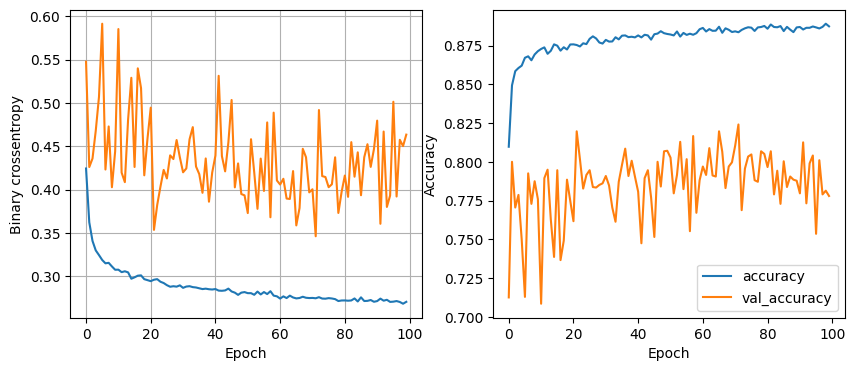

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3334
num_nodes: 16, dropout_prob: 0, lr: 0.005, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8117 - loss: 0.4116 - val_accuracy: 0.7129 - val_loss: 0.5263
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8492 - loss: 0.3520 - val_accuracy: 0.7783 - val_loss: 0.4369
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8538 - loss: 0.3379 - val_accuracy: 0.7807 - val_loss: 0.4197
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8604 - loss: 0.3270 - val_accuracy: 0.7492 - val_loss: 0.4946
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8619 - loss: 0.3224 - val_accuracy: 0.7878 - val_loss: 0.4340
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8642 - loss: 0.3183 - val_accuracy: 0.7736 - val_loss: 0.4836
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8685 - loss: 0.3149 - val_

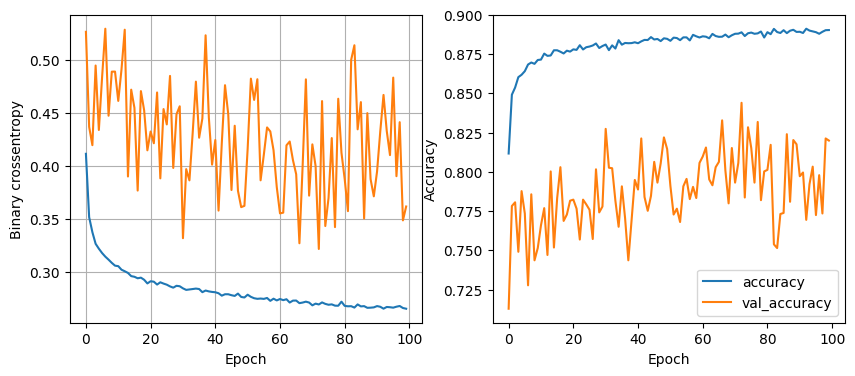

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8633 - loss: 0.3293
num_nodes: 16, dropout_prob: 0, lr: 0.005, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7856 - loss: 0.4503 - val_accuracy: 0.6590 - val_loss: 0.6242
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8472 - loss: 0.3570 - val_accuracy: 0.7376 - val_loss: 0.5436
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8598 - loss: 0.3359 - val_accuracy: 0.7600 - val_loss: 0.4693
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8657 - loss: 0.3263 - val_accuracy: 0.7393 - val_loss: 0.5214
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8685 - loss: 0.3200 - val_accuracy: 0.7464 - val_loss: 0.5114
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8697 - loss: 0.3165 - val_accuracy: 0.7566 - val_loss: 0.4892
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8689 - loss: 0.3149 - val_

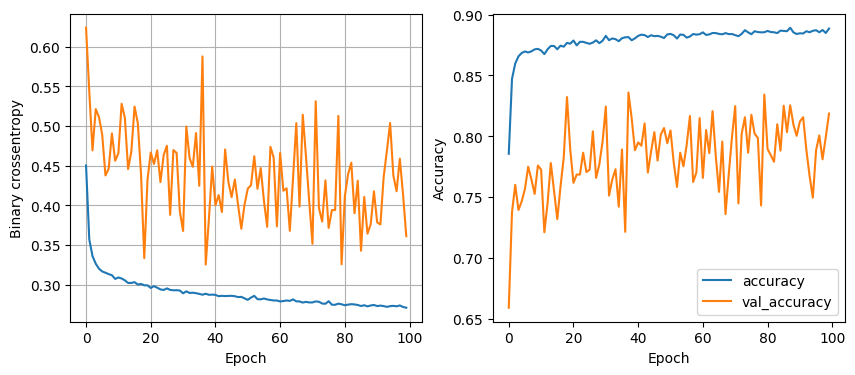

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8638 - loss: 0.3369
num_nodes: 16, dropout_prob: 0, lr: 0.005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7808 - loss: 0.4703 - val_accuracy: 0.6627 - val_loss: 0.5992
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8328 - loss: 0.3820 - val_accuracy: 0.7322 - val_loss: 0.5615
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8454 - loss: 0.3593 - val_accuracy: 0.7569 - val_loss: 0.5039
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8545 - loss: 0.3439 - val_accuracy: 0.7373 - val_loss: 0.5351
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8577 - loss: 0.3369 - val_accuracy: 0.7888 - val_loss: 0.4173
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8588 - loss: 0.3304 - val_accuracy: 0.7376 - val_loss: 0.5201
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8617 - loss: 0.3267 - val_accuracy: 0.7

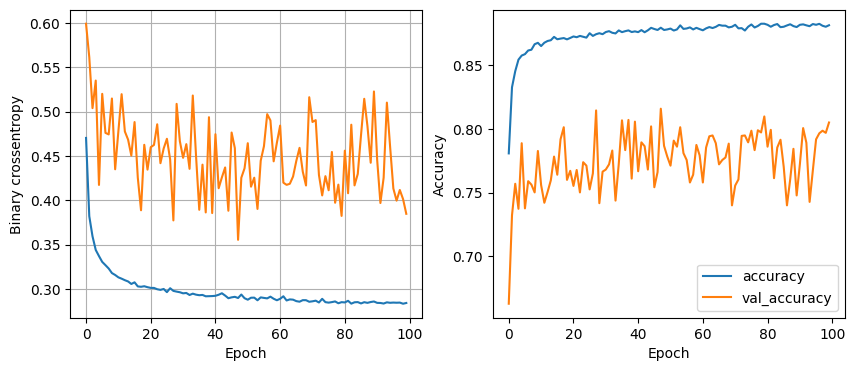

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8691 - loss: 0.3230
num_nodes: 16, dropout_prob: 0, lr: 0.001, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7736 - loss: 0.4874 - val_accuracy: 0.6153 - val_loss: 0.6275
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8151 - loss: 0.4045 - val_accuracy: 0.6769 - val_loss: 0.5796
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8326 - loss: 0.3804 - val_accuracy: 0.7088 - val_loss: 0.5490
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8448 - loss: 0.3652 - val_accuracy: 0.6973 - val_loss: 0.5889
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8484 - loss: 0.3554 - val_accuracy: 0.7275 - val_loss: 0.5539
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8522 - loss: 0.3490 - val_accuracy: 0.7722 - val_loss: 0.4823
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8569 - loss: 0.3435 - val_

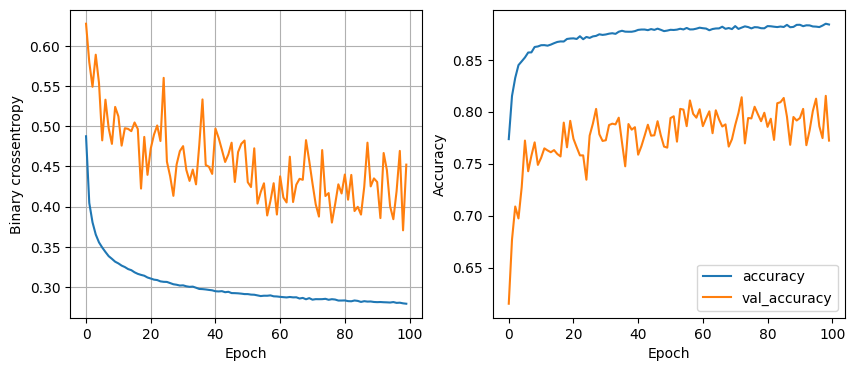

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8686 - loss: 0.3172
num_nodes: 16, dropout_prob: 0, lr: 0.001, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7268 - loss: 0.5445 - val_accuracy: 0.6407 - val_loss: 0.6150
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8143 - loss: 0.4102 - val_accuracy: 0.6827 - val_loss: 0.5633
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8301 - loss: 0.3787 - val_accuracy: 0.6861 - val_loss: 0.5790
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8455 - loss: 0.3624 - val_accuracy: 0.7159 - val_loss: 0.5493
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8518 - loss: 0.3507 - val_accuracy: 0.7495 - val_loss: 0.5060
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8556 - loss: 0.3428 - val_accuracy: 0.7458 - val_loss: 0.5156
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8595 - loss: 0.3382 - val_

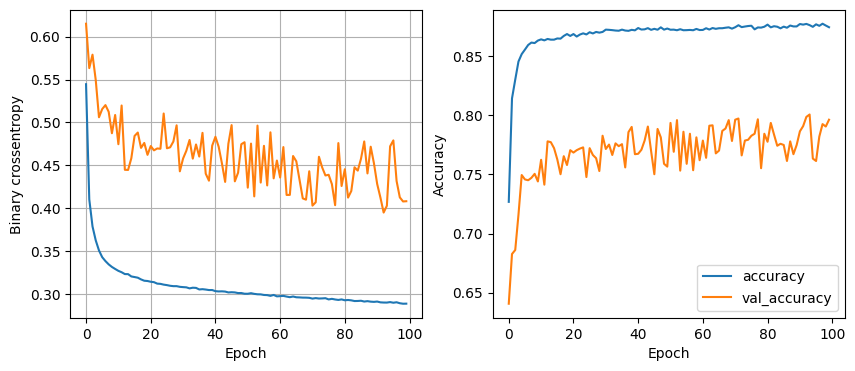

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.3203
num_nodes: 16, dropout_prob: 0, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6662 - loss: 0.6229 - val_accuracy: 0.5041 - val_loss: 0.6833
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7823 - loss: 0.4797 - val_accuracy: 0.6014 - val_loss: 0.6502
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8079 - loss: 0.4209 - val_accuracy: 0.6366 - val_loss: 0.6195
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8229 - loss: 0.3965 - val_accuracy: 0.6786 - val_loss: 0.5733
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8322 - loss: 0.3825 - val_accuracy: 0.6783 - val_loss: 0.5882
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8407 - loss: 0.3741 - val_accuracy: 0.7231 - val_loss: 0.5356
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8424 - loss: 0.3672 - val_accuracy: 0.7

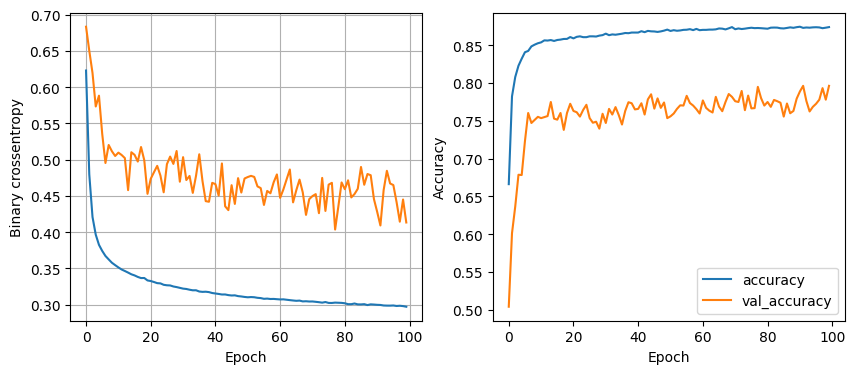

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8596 - loss: 0.3252
num_nodes: 16, dropout_prob: 0.2, lr: 0.01, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7922 - loss: 0.4537 - val_accuracy: 0.6854 - val_loss: 0.5220
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8278 - loss: 0.3984 - val_accuracy: 0.7092 - val_loss: 0.5673
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8376 - loss: 0.3798 - val_accuracy: 0.7736 - val_loss: 0.4248
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8422 - loss: 0.3673 - val_accuracy: 0.7007 - val_loss: 0.5517
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8447 - loss: 0.3605 - val_accuracy: 0.6868 - val_loss: 0.5405
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8473 - loss: 0.3603 - val_accuracy: 0.7180 - val_loss: 0.5218
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8482 - loss: 0.3569 - val

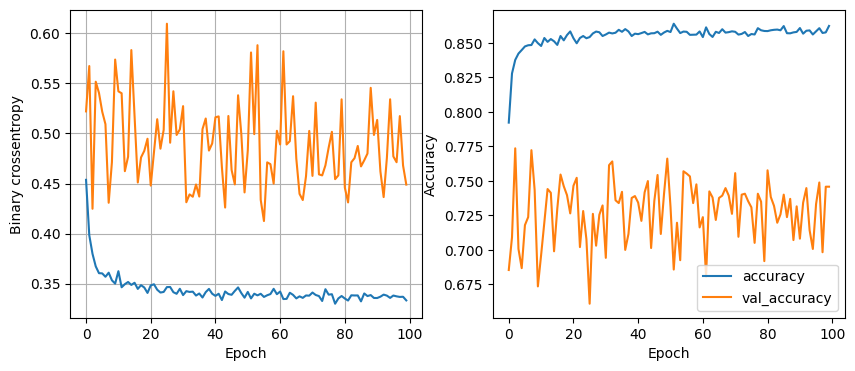

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8615 - loss: 0.3270
num_nodes: 16, dropout_prob: 0.2, lr: 0.01, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7895 - loss: 0.4585 - val_accuracy: 0.6515 - val_loss: 0.6843
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8293 - loss: 0.3979 - val_accuracy: 0.7139 - val_loss: 0.5191
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8384 - loss: 0.3798 - val_accuracy: 0.7190 - val_loss: 0.5416
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8454 - loss: 0.3705 - val_accuracy: 0.7390 - val_loss: 0.5100
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8440 - loss: 0.3641 - val_accuracy: 0.7763 - val_loss: 0.4378
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8480 - loss: 0.3605 - val_accuracy: 0.7631 - val_loss: 0.4704
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8481 - loss: 0.3595 - val

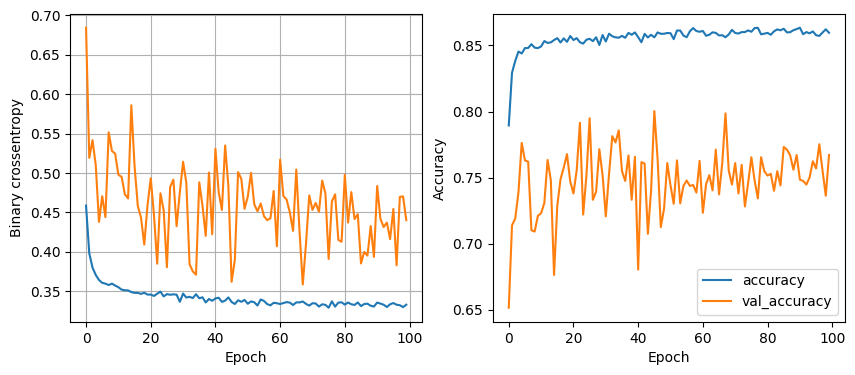

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8641 - loss: 0.3202
num_nodes: 16, dropout_prob: 0.2, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7508 - loss: 0.5086 - val_accuracy: 0.6749 - val_loss: 0.5818
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8161 - loss: 0.4188 - val_accuracy: 0.7139 - val_loss: 0.5508
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8353 - loss: 0.3887 - val_accuracy: 0.7339 - val_loss: 0.5241
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8436 - loss: 0.3711 - val_accuracy: 0.7525 - val_loss: 0.4991
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8479 - loss: 0.3667 - val_accuracy: 0.7420 - val_loss: 0.5064
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8494 - loss: 0.3579 - val_accuracy: 0.7580 - val_loss: 0.4807
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8523 - loss: 0.3543 - val_accuracy: 0.

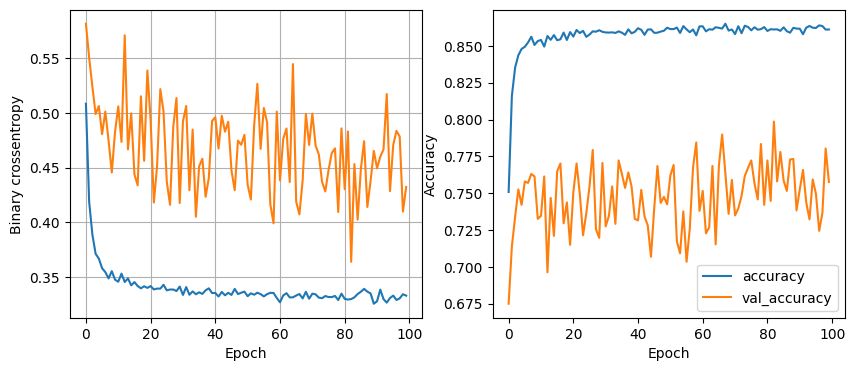

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8617 - loss: 0.3243
num_nodes: 16, dropout_prob: 0.2, lr: 0.005, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7772 - loss: 0.4766 - val_accuracy: 0.7251 - val_loss: 0.5655
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8242 - loss: 0.4036 - val_accuracy: 0.6607 - val_loss: 0.6561
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8382 - loss: 0.3846 - val_accuracy: 0.7163 - val_loss: 0.5288
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8417 - loss: 0.3702 - val_accuracy: 0.7329 - val_loss: 0.5245
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8441 - loss: 0.3658 - val_accuracy: 0.7085 - val_loss: 0.5782
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8469 - loss: 0.3573 - val_accuracy: 0.7498 - val_loss: 0.4625
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8497 - loss: 0.3577 - va

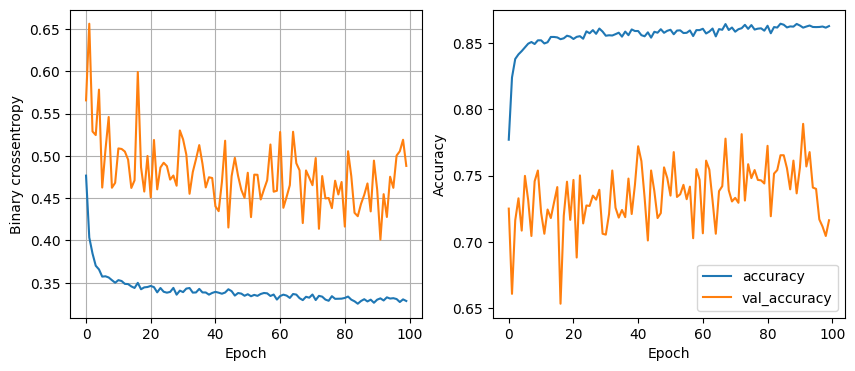

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8633 - loss: 0.3226
num_nodes: 16, dropout_prob: 0.2, lr: 0.005, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7631 - loss: 0.4934 - val_accuracy: 0.6495 - val_loss: 0.6387
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8148 - loss: 0.4147 - val_accuracy: 0.6739 - val_loss: 0.6145
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8280 - loss: 0.3946 - val_accuracy: 0.6895 - val_loss: 0.5726
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8368 - loss: 0.3830 - val_accuracy: 0.7549 - val_loss: 0.4700
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8379 - loss: 0.3767 - val_accuracy: 0.7298 - val_loss: 0.4902
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8458 - loss: 0.3684 - val_accuracy: 0.6481 - val_loss: 0.6007
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8471 - loss: 0.3626 - va

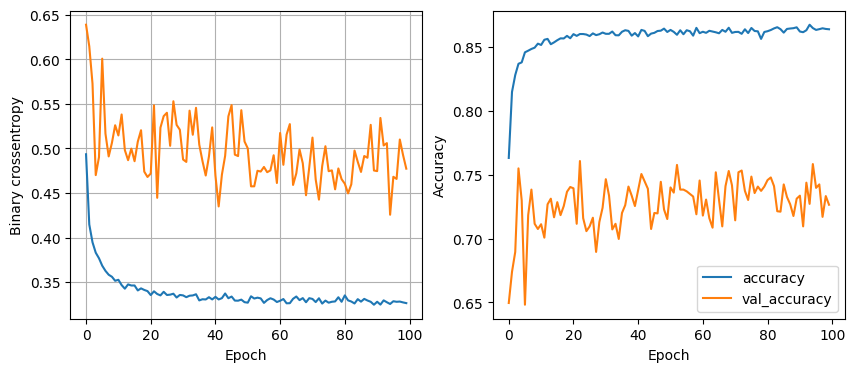

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3189
num_nodes: 16, dropout_prob: 0.2, lr: 0.005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7593 - loss: 0.5041 - val_accuracy: 0.6092 - val_loss: 0.6483
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8017 - loss: 0.4361 - val_accuracy: 0.6841 - val_loss: 0.6173
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8161 - loss: 0.4172 - val_accuracy: 0.7163 - val_loss: 0.5371
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8284 - loss: 0.3984 - val_accuracy: 0.7058 - val_loss: 0.5617
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8412 - loss: 0.3830 - val_accuracy: 0.7085 - val_loss: 0.5773
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8405 - loss: 0.3805 - val_accuracy: 0.7525 - val_loss: 0.5158
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8479 - loss: 0.3670 - val_accuracy: 0

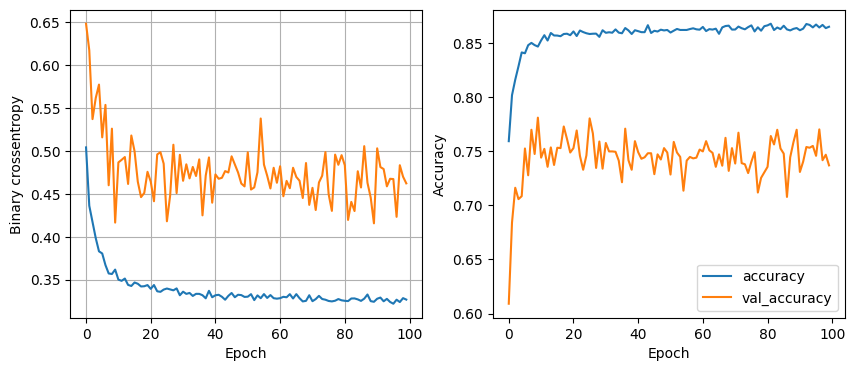

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3164
num_nodes: 16, dropout_prob: 0.2, lr: 0.001, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7063 - loss: 0.5706 - val_accuracy: 0.5369 - val_loss: 0.7022
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7787 - loss: 0.4717 - val_accuracy: 0.5969 - val_loss: 0.6434
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7932 - loss: 0.4444 - val_accuracy: 0.6227 - val_loss: 0.6256
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7989 - loss: 0.4363 - val_accuracy: 0.6637 - val_loss: 0.5802
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8074 - loss: 0.4225 - val_accuracy: 0.6776 - val_loss: 0.5985
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8177 - loss: 0.4134 - val_accuracy: 0.6875 - val_loss: 0.5824
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8226 - loss: 0.4067 - va

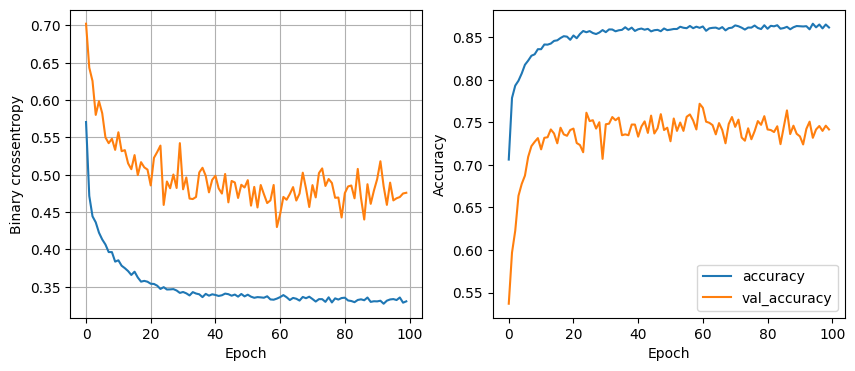

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8657 - loss: 0.3213
num_nodes: 16, dropout_prob: 0.2, lr: 0.001, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7203 - loss: 0.5460 - val_accuracy: 0.5973 - val_loss: 0.6496
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7795 - loss: 0.4659 - val_accuracy: 0.6254 - val_loss: 0.6374
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7837 - loss: 0.4557 - val_accuracy: 0.6400 - val_loss: 0.6305
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7930 - loss: 0.4440 - val_accuracy: 0.6492 - val_loss: 0.6156
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8006 - loss: 0.4371 - val_accuracy: 0.6536 - val_loss: 0.6199
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8039 - loss: 0.4287 - val_accuracy: 0.6803 - val_loss: 0.5757
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8057 - loss: 0.4243 - va

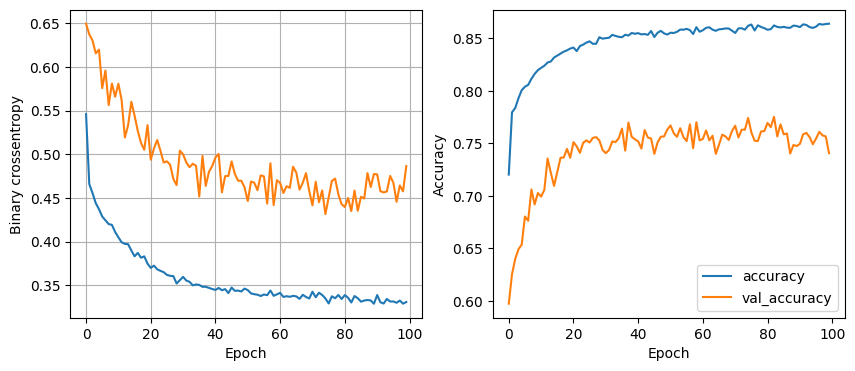

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8659 - loss: 0.3167
num_nodes: 16, dropout_prob: 0.2, lr: 0.001, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6317 - loss: 0.6222 - val_accuracy: 0.4722 - val_loss: 0.7169
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5131 - val_accuracy: 0.5746 - val_loss: 0.6864
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7716 - loss: 0.4778 - val_accuracy: 0.6380 - val_loss: 0.6519
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7878 - loss: 0.4550 - val_accuracy: 0.6739 - val_loss: 0.6050
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4445 - val_accuracy: 0.6654 - val_loss: 0.6122
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8048 - loss: 0.4361 - val_accuracy: 0.6732 - val_loss: 0.6090
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8105 - loss: 0.4269 - val_accuracy: 

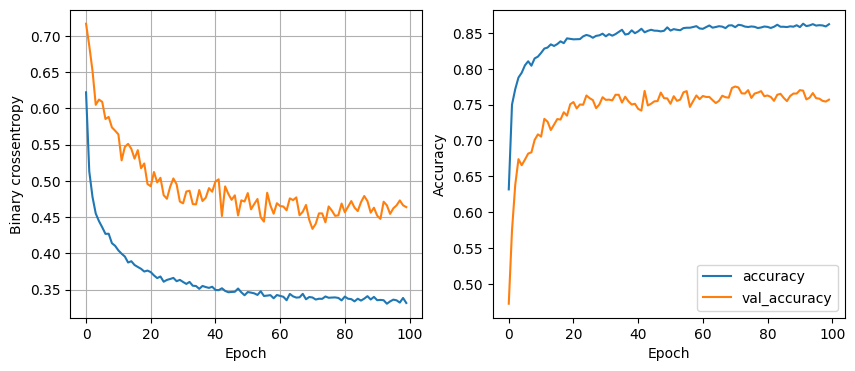

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3213
num_nodes: 32, dropout_prob: 0, lr: 0.01, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8324 - loss: 0.3875 - val_accuracy: 0.7820 - val_loss: 0.4456
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8540 - loss: 0.3435 - val_accuracy: 0.7217 - val_loss: 0.5220
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8629 - loss: 0.3309 - val_accuracy: 0.7519 - val_loss: 0.4813
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8637 - loss: 0.3211 - val_accuracy: 0.8129 - val_loss: 0.3439
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8667 - loss: 0.3192 - val_accuracy: 0.7478 - val_loss: 0.4906
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8703 - loss: 0.3130 - val_accuracy: 0.7556 - val_loss: 0.4185
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8703 - loss: 0.3124 - val_a

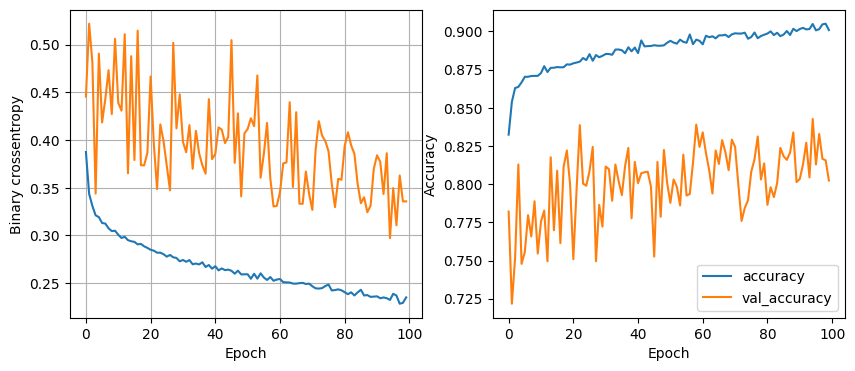

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8599 - loss: 0.4132
num_nodes: 32, dropout_prob: 0, lr: 0.01, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8190 - loss: 0.4003 - val_accuracy: 0.7129 - val_loss: 0.5771
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8526 - loss: 0.3454 - val_accuracy: 0.8193 - val_loss: 0.3667
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8627 - loss: 0.3306 - val_accuracy: 0.7529 - val_loss: 0.4718
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss: 0.3236 - val_accuracy: 0.7583 - val_loss: 0.4483
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8662 - loss: 0.3180 - val_accuracy: 0.7329 - val_loss: 0.4884
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.3148 - val_accuracy: 0.7756 - val_loss: 0.4112
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8683 - loss: 0.3140 - val_a

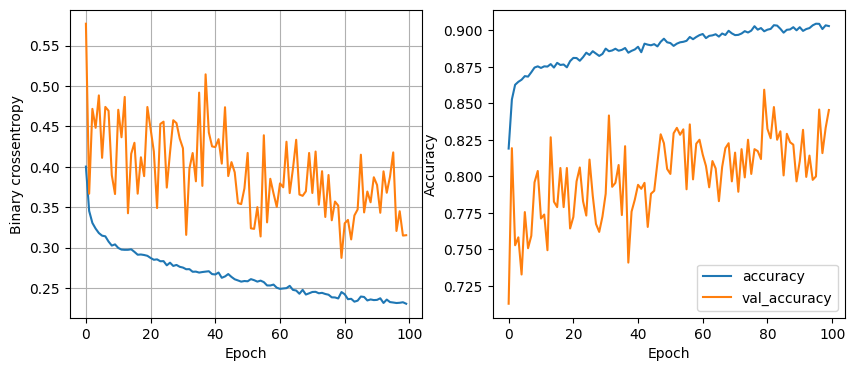

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8541 - loss: 0.4292
num_nodes: 32, dropout_prob: 0, lr: 0.01, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8234 - loss: 0.4020 - val_accuracy: 0.7064 - val_loss: 0.5722
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8559 - loss: 0.3439 - val_accuracy: 0.6644 - val_loss: 0.6459
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8629 - loss: 0.3298 - val_accuracy: 0.7519 - val_loss: 0.4580
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8623 - loss: 0.3207 - val_accuracy: 0.7678 - val_loss: 0.4405
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8651 - loss: 0.3209 - val_accuracy: 0.7461 - val_loss: 0.4741
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8672 - loss: 0.3141 - val_accuracy: 0.7888 - val_loss: 0.4004
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8688 - loss: 0.3098 - val_accuracy: 0.73

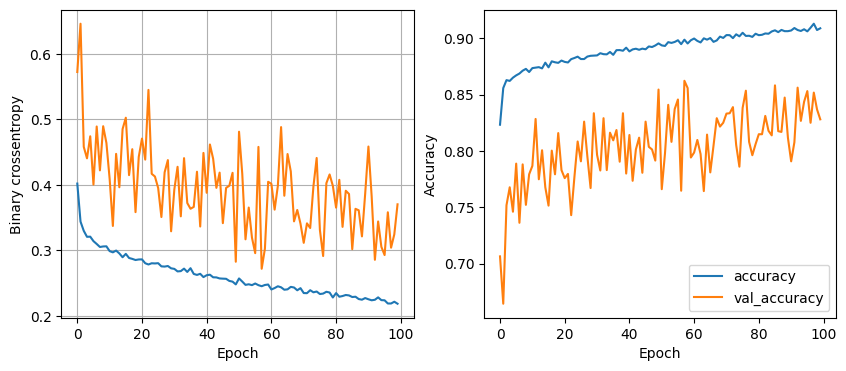

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8617 - loss: 0.3936
num_nodes: 32, dropout_prob: 0, lr: 0.005, batch_size: 32
Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8268 - loss: 0.3929 - val_accuracy: 0.7142 - val_loss: 0.5600
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8514 - loss: 0.3453 - val_accuracy: 0.7441 - val_loss: 0.4724
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8618 - loss: 0.3313 - val_accuracy: 0.8000 - val_loss: 0.3716
Epoch 4/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8668 - loss: 0.3215 - val_accuracy: 0.7908 - val_loss: 0.4138
Epoch 5/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8672 - loss: 0.3152 - val_accuracy: 0.7797 - val_loss: 0.4396
Epoch 6/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8697 - loss: 0.3099 - val_accuracy: 0.7475 - val_loss: 0.5107
Epoch 7/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8728 - loss: 0.3065 - val_

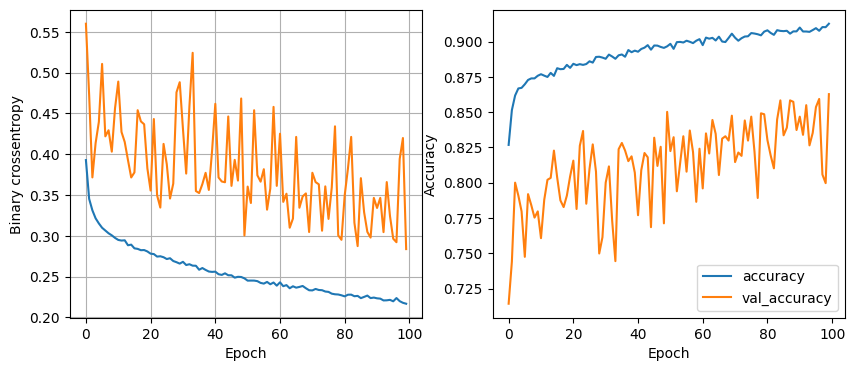

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8594 - loss: 0.3950
num_nodes: 32, dropout_prob: 0, lr: 0.005, batch_size: 64
Epoch 1/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8184 - loss: 0.4062 - val_accuracy: 0.6712 - val_loss: 0.6396
Epoch 2/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8492 - loss: 0.3510 - val_accuracy: 0.7651 - val_loss: 0.4715
Epoch 3/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8578 - loss: 0.3374 - val_accuracy: 0.7563 - val_loss: 0.4818
Epoch 4/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8620 - loss: 0.3283 - val_accuracy: 0.7275 - val_loss: 0.5549
Epoch 5/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8628 - loss: 0.3202 - val_accuracy: 0.8136 - val_loss: 0.3730
Epoch 6/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8670 - loss: 0.3159 - val_accuracy: 0.7427 - val_loss: 0.4769
Epoch 7/100
185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8685 - loss: 0.3151 - val_

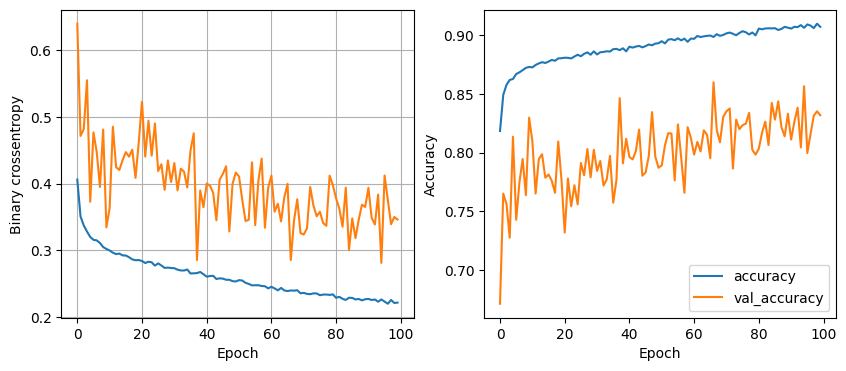

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8644 - loss: 0.3658
num_nodes: 32, dropout_prob: 0, lr: 0.005, batch_size: 128
Epoch 1/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8072 - loss: 0.4265 - val_accuracy: 0.7990 - val_loss: 0.4167
Epoch 2/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8508 - loss: 0.3554 - val_accuracy: 0.7590 - val_loss: 0.4966
Epoch 3/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8558 - loss: 0.3435 - val_accuracy: 0.7366 - val_loss: 0.5460
Epoch 4/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8591 - loss: 0.3297 - val_accuracy: 0.7861 - val_loss: 0.4300
Epoch 5/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8634 - loss: 0.3245 - val_accuracy: 0.7851 - val_loss: 0.4303
Epoch 6/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8655 - loss: 0.3173 - val_accuracy: 0.7600 - val_loss: 0.4745
Epoch 7/100
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8670 - loss: 0.3160 - val_accuracy: 0.7

In [ ]:
least_val_loss= float('inf')
least_loss_model= None
epochs=100
for num_nodes in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for lr in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f'num_nodes: {num_nodes}, dropout_prob: {dropout_prob}, lr: {lr}, batch_size: {batch_size}')
        model, history= train_model(X_train, Y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
        plot_history(history)
        val_loss_metrics = model.evaluate(X_valid, Y_valid)
        val_loss = val_loss_metrics[0] # Extract the loss value
        if val_loss < least_val_loss:
          least_val_loss= val_loss
          least_loss_model= model

In [37]:
y_pred= least_loss_model.predict(X_test)
y_pred= (y_pred>0.5).astype(int).reshape(-1,)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [39]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.73      0.79      1303
           1       0.87      0.95      0.91      2501

    accuracy                           0.87      3804
   macro avg       0.87      0.84      0.85      3804
weighted avg       0.87      0.87      0.87      3804

